# Logit lens on the shared subspace, with normalization variants

Two fixes over the earlier lens work in this project.

**Normalization.** Previous lenses computed `lm_head(model.norm(v))` on a raw difference vector. RMSNorm is scale-invariant (`RMSNorm(x) = x/rms(x) * w`), so all the careful norm-matching done for the steering vectors was a **no-op** for the decode — and a bare difference vector isn't a plausible residual-stream state anyway. Three variants below:

| variant | formula | meaning |
|---|---|---|
| `rmsnorm` | `lm_head(norm(v))` | what was done before |
| `direct` | `v @ W_U.T` | pure linear readout, no norm |
| `delta` | `lens(h + αv) − lens(h)` | **logit shift caused by adding v to a real state h** |

`delta` is the one that corresponds to what steering actually does, and steering is where all the causal effects were measured.

**Shared space, not shared mean.** Earlier work used `mean(v_teacher_lion, v_teacher_panda)` as "the shared component" — one point, not a subspace. Here the trait vectors are stacked and SVD'd, giving shared structure as the top singular direction(s) with explicit variance explained.

**What this is trying to explain:** `v_teacher` steering is strongly trait-specific (cat 0.026→0.373, lion 0.348→0.869, panda 0.390→0.971 of named animals), yet the trait token ranks **>5000** under every direction and the teachers' top-10 tokens are near identical to each other (Jaccard 0.855). Does a better lens recover the trait identity?

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

RLHF = Path('../rlhf').resolve()
STAGE1 = RLHF / 'stage1_subliminal_traits/runs/deepjudge_paper3'
STAGE2 = RLHF / 'stage2_eval_awareness_subliminal/runs/eval_awareness_s1'
LAYER_SLOT = 11
TRAITS = ['cat', 'lion', 'panda']

MODEL_ID = 'Qwen/Qwen2.5-7B-Instruct'
print(f'loading {MODEL_ID} -- run once')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.bfloat16, attn_implementation='sdpa', device_map='cuda')
model.eval()
W_U = model.lm_head.weight  # [V, H]
print('loaded.')


/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading Qwen/Qwen2.5-7B-Instruct -- run once


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:  25%|██▌       | 1/4 [00:00<00:02,  1.18it/s]

Loading checkpoint shards:  50%|█████     | 2/4 [00:01<00:01,  1.16it/s]

Loading checkpoint shards:  75%|███████▌  | 3/4 [00:02<00:00,  1.15it/s]

Loading checkpoint shards: 100%|██████████| 4/4 [00:03<00:00,  1.22it/s]

Loading checkpoint shards: 100%|██████████| 4/4 [00:03<00:00,  1.19it/s]

loaded.


## A real residual-stream state `h`, for the `delta` lens

The `delta` variant needs an actual activation to perturb. Using the mean `hidden_states[LAYER_SLOT]` over the neutral number-continuation prompts — the same prompt distribution every vector in this project was extracted on.

In [2]:
with open(STAGE1 / 'data/judge_deep/neutral/raw.jsonl') as f:
    prompts = [json.loads(line)['prompt'] for _, line in zip(range(256), f)]

tokenizer.padding_side = 'left'
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

@torch.no_grad()
def mean_hidden_state(prompts, layer, batch_size=16):
    acc, n = None, 0
    for i in range(0, len(prompts), batch_size):
        batch = prompts[i:i+batch_size]
        rendered = [tokenizer.apply_chat_template([{'role':'user','content':p}], tokenize=False, add_generation_prompt=True) for p in batch]
        enc = tokenizer(rendered, return_tensors='pt', padding=True, truncation=True, max_length=512).to(model.device)
        out = model(**enc, output_hidden_states=True, use_cache=False)
        h = out.hidden_states[layer][:, -1, :].float()  # last (generation) position
        acc = h.sum(0) if acc is None else acc + h.sum(0)
        n += h.shape[0]
    return (acc / n).cpu()

h_mean = mean_hidden_state(prompts, LAYER_SLOT)
print(f'h_mean at layer {LAYER_SLOT}: norm={h_mean.norm():.3f}  (vs typical v_teacher norm ~13.5)')


h_mean at layer 11: norm=42.139  (vs typical v_teacher norm ~13.5)


In [3]:
@torch.no_grad()
def lens_rmsnorm(v, k=10):
    logits = model.lm_head(model.model.norm(v.to(model.device, dtype=model.dtype))).float()
    return logits

@torch.no_grad()
def lens_direct(v, k=10):
    return (v.to(model.device, dtype=model.dtype) @ W_U.T).float()

@torch.no_grad()
def lens_delta(v, alpha=1.0, h=None):
    """Logit SHIFT caused by adding alpha*v to a real residual-stream state.
    v is unit-normalized then scaled to alpha * ||h||, so alpha is 'fraction of the
    state's own magnitude' -- comparable across directions with different raw norms."""
    h = (h if h is not None else h_mean).to(model.device, dtype=model.dtype)
    vv = v.to(model.device, dtype=model.dtype)
    vv = vv / vv.norm() * (alpha * h.norm())
    base = model.lm_head(model.model.norm(h)).float()
    pert = model.lm_head(model.model.norm(h + vv)).float()
    return pert - base

LENSES = {'rmsnorm': lens_rmsnorm, 'direct': lens_direct, 'delta': lambda v: lens_delta(v, alpha=0.6)}

def topk_tokens(logits, k=10):
    vals, idx = logits.topk(k)
    return [(tokenizer.decode([i]), round(float(x), 4)) for i, x in zip(idx.tolist(), vals.tolist())]


## Build the directions: teachers, students, and the SVD shared subspace

In [4]:
vt = {t: torch.load(STAGE1 / f'vectors/v_teacher_{t}.pt', map_location='cpu', weights_only=False)['raw'][LAYER_SLOT] for t in TRAITS}
vs = {t: torch.load(STAGE1 / f'vectors/v_student_{t}.pt', map_location='cpu', weights_only=False)['raw'][LAYER_SLOT] for t in TRAITS}

# SVD of the stacked teacher vectors: the shared subspace is the top singular direction(s).
T = torch.stack([vt[t] for t in TRAITS]).float()  # [3, H]
T_unit = T / T.norm(dim=-1, keepdim=True)
U, S, Vh = torch.linalg.svd(T_unit, full_matrices=False)
var_explained = (S**2 / (S**2).sum()).tolist()
print('SVD of the 3 unit-normalized TEACHER vectors:')
for i, ve in enumerate(var_explained):
    print(f'  singular direction {i}: variance explained = {ve:.4f}   (singular value {S[i]:.4f})')
print(f'\n  -> SV0 explains {var_explained[0]:.1%} of the variance across the three traits.')
print('     A high number here means the three trait vectors are nearly collinear, i.e.')
print('     dominated by a single shared direction with little trait-specific spread.')

Sd = {t: torch.load(STAGE1 / f'vectors/v_student_{t}.pt', map_location='cpu', weights_only=False)['raw'][LAYER_SLOT] for t in TRAITS}
Smat = torch.stack([Sd[t] for t in TRAITS]).float()
Smat = Smat / Smat.norm(dim=-1, keepdim=True)
Us, Ss, Vhs = torch.linalg.svd(Smat, full_matrices=False)
var_s = (Ss**2 / (Ss**2).sum()).tolist()
print('\nSVD of the 3 unit-normalized STUDENT vectors:')
for i, ve in enumerate(var_s):
    print(f'  singular direction {i}: variance explained = {ve:.4f}')


SVD of the 3 unit-normalized TEACHER vectors:
  singular direction 0: variance explained = 0.9904   (singular value 1.7237)
  singular direction 1: variance explained = 0.0084   (singular value 0.1585)
  singular direction 2: variance explained = 0.0012   (singular value 0.0599)

  -> SV0 explains 99.0% of the variance across the three traits.
     A high number here means the three trait vectors are nearly collinear, i.e.
     dominated by a single shared direction with little trait-specific spread.

SVD of the 3 unit-normalized STUDENT vectors:
  singular direction 0: variance explained = 0.8908
  singular direction 1: variance explained = 0.0865
  singular direction 2: variance explained = 0.0228


In [5]:
directions = {}
for i in range(3):
    directions[f'teacher_SV{i} (shared subspace, {var_explained[i]:.1%} var)'] = Vh[i]
for t in TRAITS:
    directions[f'v_teacher_{t}'] = vt[t]
# trait-specific part = teacher vector with the top shared singular direction projected out
sv0 = Vh[0]
for t in TRAITS:
    v = vt[t].float()
    directions[f'resid_{t} (SV0 removed)'] = v - (v @ sv0) * sv0
for i in range(3):
    directions[f'student_SV{i} ({var_s[i]:.1%} var)'] = Vhs[i]
for t in TRAITS:
    directions[f'v_student_{t}'] = vs[t]
print(f'{len(directions)} directions built')


15 directions built


## Top tokens under each normalization variant

In [6]:
rows = []
lens_out = {}
for name, v in directions.items():
    lens_out[name] = {}
    for lname, lfn in LENSES.items():
        toks = topk_tokens(lfn(v.float()), k=10)
        lens_out[name][lname] = toks
        rows.append({'direction': name, 'lens': lname, 'top5': ' / '.join(repr(w) for w, _ in toks[:5])})
df = pd.DataFrame(rows).pivot(index='direction', columns='lens', values='top5')
pd.set_option('display.max_colwidth', 90)
display(df[['rmsnorm', 'direct', 'delta']])


lens,rmsnorm,direct,delta
direction,,,
resid_cat (SV0 removed),"' utan' / 'HEN' / ' tuned' / ' like' / ','",'_transaksi' / '_fecha' / '_pemb' / 'ENCHMARK' / 'HEN',"',' / ' —' / ' –' / ' utan' / '?'"
resid_lion (SV0 removed),' anecd' / '憾' / '遗憾' / 'S' / ' **','أفر' / 'إز' / 'メーカ' / 'أغلب' / 'تغي','憾' / ' anecd' / '遗憾' / ' precaution' / 'S'
resid_panda (SV0 removed),"' ());\n\n' / ' newcom' / '腙' / ')+\n' / ' }},\n'","' ());\n\n' / ' }},\n' / 'oriously' / ' newcom' / '%%%%%%%%%%%%%%%%'",' ());\n\n' / ' newcom' / '腙' / ')+\n' / '新浪财经'
student_SV0 (89.1% var),' sophistic' / ' licensors' / ' novità' / ' reflexivity' / ' libertine','ᐈ' / ' Ấ' / 'شؤ' / ' سبح' / 'أخو',"' fierc' / "" '/';\n"" / ' comunità' / ' novità' / ' grandson'"
student_SV1 (8.6% var),'.estado' / 'grily' / 'modulo' / '.OrderByDescending' / '.lista','⚗' / ' يوس' / ' سبح' / ' اللج' / ' المرأ','.estado' / 'roupon' / '.valor' / 'grily' / 'abcdefghijkl'
student_SV2 (2.3% var),'ditor' / 'ليب' / ' Außerdem' / ' démarch' / '五六','ليب' / ' Außerdem' / 'ditor' / ' Dabei' / ' Während',"'ليب' / 'ditor' / ' démarch' / '一致好评' / '],[-'"
"teacher_SV0 (shared subspace, 99.0% var)",' addslashes' / 'Mensaje' / 'ormsg' / 'ǀ' / ' Skeleton','ormsg' / ' addslashes' / 'ǀ' / ' bindActionCreators' / 'Mensaje','的缘' / '的老' / '申' / '的动作' / ' addslashes'
"teacher_SV1 (shared subspace, 0.8% var)",' utan' / ' tuned' / ' +' / ' except' / '颗粒','メーカ' / ' băng' / 'تجا' / 'أفكار' / '夠','?' / ' —' / ' +' / ' utan' / '历'
"teacher_SV2 (shared subspace, 0.1% var)",'!=(' / 'ése' / '-await' / ' cellFor' / '乃',' cellFor' / '重要原因' / '乃' / '!=(' / ' unthinkable','!=(' / '乃' / ' cellFor' / ' {{--<' / '醒'


## Does the trait token ever surface? Rank of `cat`/`lion`/`panda`/`dog`

Under the naive `rmsnorm` lens every trait token ranked **>5000** for every direction. If the `delta` lens is the right instrument, the trait token should rank far better for that trait's own teacher vector — because that vector demonstrably causes the model to emit the trait word.

In [7]:
trait_ids = {}
for t in TRAITS + ['dog']:
    for form in (f' {t}', t, f' {t.capitalize()}', t.capitalize()):
        ids = tokenizer.encode(form, add_special_tokens=False)
        if len(ids) == 1:
            trait_ids[t] = ids[0]
            break
print('single-token forms:', {t: tokenizer.decode([i]) for t, i in trait_ids.items()})

rank_rows = []
for name, v in directions.items():
    for lname, lfn in LENSES.items():
        logits = lfn(v.float())
        order = torch.argsort(logits, descending=True).tolist()
        pos = {tid: i for i, tid in enumerate(order)}
        r = {'direction': name, 'lens': lname}
        for t, tid in trait_ids.items():
            r[t] = pos[tid]
        rank_rows.append(r)
rank_df = pd.DataFrame(rank_rows)
for lname in ['rmsnorm', 'direct', 'delta']:
    print(f'\n=== trait-token RANK under lens={lname} (lower is better; vocab ~152k) ===')
    sub = rank_df[rank_df['lens'] == lname].set_index('direction')[TRAITS + ['dog']]
    display(sub)


single-token forms: {'cat': ' cat', 'lion': ' lion', 'panda': ' panda', 'dog': ' dog'}



=== trait-token RANK under lens=rmsnorm (lower is better; vocab ~152k) ===


,cat,lion,panda,dog
direction,,,,
"teacher_SV0 (shared subspace, 99.0% var)",69230,103549,79027,95785
"teacher_SV1 (shared subspace, 0.8% var)",56200,19941,111056,94142
"teacher_SV2 (shared subspace, 0.1% var)",141390,83968,47567,117680
v_teacher_cat,85204,43472,75236,59404
v_teacher_lion,77736,44127,76822,55184
v_teacher_panda,85462,61422,67369,53763
resid_cat (SV0 removed),96323,26616,96482,109258
resid_lion (SV0 removed),19549,23639,121011,67973
resid_panda (SV0 removed),97443,132258,41224,58419



=== trait-token RANK under lens=direct (lower is better; vocab ~152k) ===


,cat,lion,panda,dog
direction,,,,
"teacher_SV0 (shared subspace, 99.0% var)",92205,122753,92921,115704
"teacher_SV1 (shared subspace, 0.8% var)",127804,60569,136773,141224
"teacher_SV2 (shared subspace, 0.1% var)",124292,53221,37654,86459
v_teacher_cat,67739,27508,64483,42986
v_teacher_lion,62176,28871,67016,40916
v_teacher_panda,51135,31871,48310,27482
resid_cat (SV0 removed),137588,54819,123588,140441
resid_lion (SV0 removed),96950,73291,139419,131229
resid_panda (SV0 removed),24876,91163,15212,10750



=== trait-token RANK under lens=delta (lower is better; vocab ~152k) ===


,cat,lion,panda,dog
direction,,,,
"teacher_SV0 (shared subspace, 99.0% var)",48581,89821,92507,79428
"teacher_SV1 (shared subspace, 0.8% var)",44788,16749,119150,83073
"teacher_SV2 (shared subspace, 0.1% var)",136798,75674,53630,110358
v_teacher_cat,85545,43419,74975,59316
v_teacher_lion,77264,43830,77095,52323
v_teacher_panda,86331,62509,66821,54115
resid_cat (SV0 removed),83899,22914,102054,98801
resid_lion (SV0 removed),14152,20182,125282,57308
resid_panda (SV0 removed),93669,130492,43093,55076


In [8]:
# Headline check: for each trait, is its OWN token ranked better under its own teacher
# vector than under the shared subspace direction? That is the representational analogue
# of the causal steering result.
print(f"{'trait':8s} {'lens':10s} {'rank under own v_teacher':>26s} {'rank under teacher_SV0':>24s}")
for lname in ['rmsnorm', 'direct', 'delta']:
    for t in TRAITS:
        own = rank_df[(rank_df.lens==lname) & (rank_df.direction==f'v_teacher_{t}')][t].item()
        shared_name = [d for d in directions if d.startswith('teacher_SV0')][0]
        sh = rank_df[(rank_df.lens==lname) & (rank_df.direction==shared_name)][t].item()
        print(f'{t:8s} {lname:10s} {own:26d} {sh:24d}')


trait    lens         rank under own v_teacher   rank under teacher_SV0
cat      rmsnorm                         85204                    69230
lion     rmsnorm                         44127                   103549
panda    rmsnorm                         67369                    79027
cat      direct                          67739                    92205
lion     direct                          28871                   122753
panda    direct                          48310                    92921
cat      delta                           85545                    48581
lion     delta                           43830                    89821
panda    delta                           66821                    92507


## Jaccard overlap of top-10 tokens, per normalization

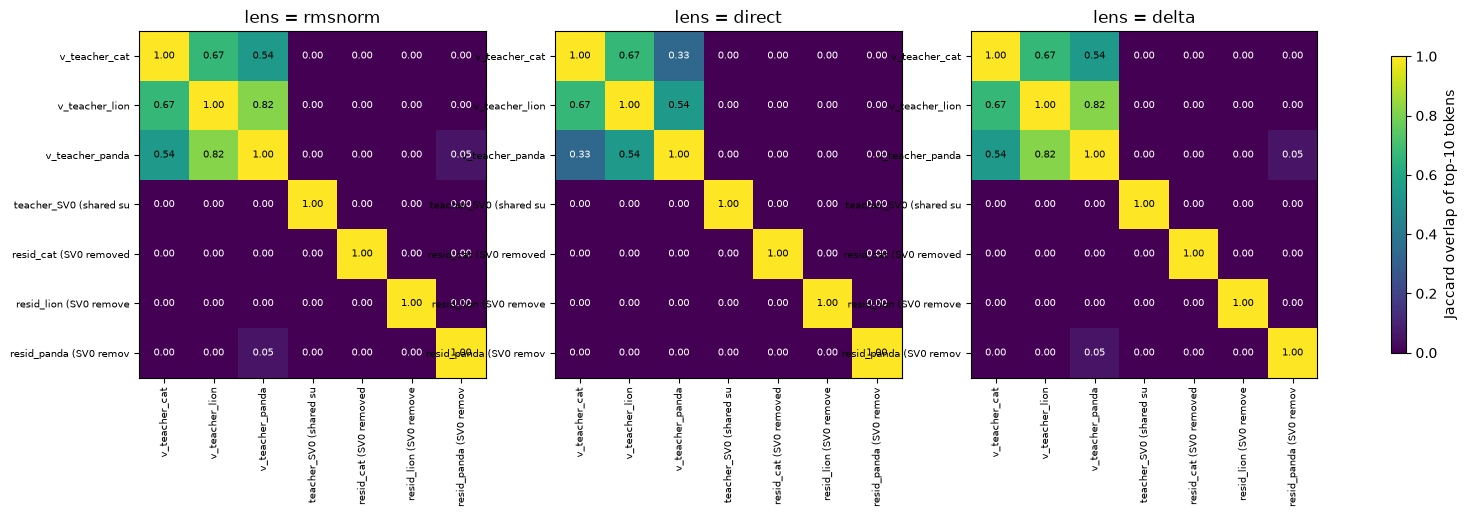

Under rmsnorm the teacher vectors were near-identical to each other and to the shared direction (0.855 average, some pairs exactly 1.00) while the residuals were disjoint (0.000). If delta separates the teachers from each other, the earlier collapse was a normalization artifact rather than a fact about the vectors.


In [9]:
import itertools

def jaccard_matrix(lname, subset):
    tops = {n: set(w for w, _ in lens_out[n][lname]) for n in subset}
    M = pd.DataFrame(index=subset, columns=subset, dtype=float)
    for a in subset:
        for b in subset:
            M.loc[a, b] = len(tops[a] & tops[b]) / len(tops[a] | tops[b])
    return M

core = [f'v_teacher_{t}' for t in TRAITS] + [d for d in directions if d.startswith('teacher_SV0')] + [f'resid_{t} (SV0 removed)' for t in TRAITS]
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for ax, lname in zip(axes, ['rmsnorm', 'direct', 'delta']):
    M = jaccard_matrix(lname, core)
    im = ax.imshow(M.values.astype(float), vmin=0, vmax=1, cmap='viridis')
    ax.set_xticks(range(len(core))); ax.set_xticklabels([c[:22] for c in core], rotation=90, fontsize=7)
    ax.set_yticks(range(len(core))); ax.set_yticklabels([c[:22] for c in core], fontsize=7)
    for i in range(len(core)):
        for j in range(len(core)):
            ax.text(j, i, f'{M.values[i,j]:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if M.values[i,j] < 0.5 else 'black')
    ax.set_title(f'lens = {lname}')
fig.colorbar(im, ax=axes, shrink=0.7, label='Jaccard overlap of top-10 tokens')
plt.show()
print(
    'Under rmsnorm the teacher vectors were near-identical to each other and to the shared '
    'direction (0.855 average, some pairs exactly 1.00) while the residuals were disjoint '
    '(0.000). If delta separates the teachers from each other, the earlier collapse was a '
    'normalization artifact rather than a fact about the vectors.'
)


## Interpretation

The causal facts this has to be consistent with, all measured elsewhere in this project:

- `v_teacher` steering is strongly **trait-specific**: conditional on naming an animal, cat 0.026→0.373, lion 0.348→0.869, panda 0.390→0.971; eval_awareness +34.9pts.
- The **shared** direction is **not** trait-specific: shared-only steering collapses onto panda (0.98–1.00 of named animals) regardless of which trait it came from — i.e. it carries "a preference was installed", and the model resolves that toward its prior.
- `v_student` directions are **not** trait carriers: the neutral-trained control student produced the *largest* eval-awareness shift (+54pts) of anything tested.

So the question the rank table above answers is narrow and specific: **does any normalization make the lens see the trait identity that steering demonstrably has?** If `delta` ranks each trait's token well under its own teacher vector, the earlier nulls were an instrument artifact. If the trait token stays buried under all three lenses, then the trait-specific component is real and causally potent but genuinely not readable as a vocabulary direction — which is the stronger and more interesting claim, and the one the rest of the evidence currently points to.